# Water Data Analysis Tutorial

這份 notebook 示範如何使用 template 內建模組，對 `water.dat` 做一套完整的近代物理實驗資料分析流程：

1. 讀取資料
2. 加入量測不確定度
3. 使用 `fitting.py` 做線性回歸與斜率不確定度傳遞
4. 使用 `formatting.py` 產生適合報告的 LaTeX 表格
5. 使用 `plot_settings.py` 畫出風格一致的回歸圖


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display
from uncertainties import ufloat

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.analysis.fitting import excel_style_regression_with_propagation
from src.analysis.formatting import ufloat_to_paren
from src.visualization import create_figure, save_figure

DATA_PATH = PROJECT_ROOT / "data" / "interim" / "water.dat"
DATA_PATH

PosixPath('/Users/dengensheng/Developer/近代物理實驗/Modern_Physics_Experiment_Data_Analysis/data/interim/water.dat')

## 1. 讀取原始資料

這份資料包含三欄：

- `distance_mm`：探頭到反射面距離
- `first_reflection_time_us`：第一次回波時間
- `first_reflection_amplitude_V`：第一次回波振幅

這份教學主要示範用前兩欄做聲速回歸。

In [2]:
df = pd.read_csv(DATA_PATH, sep=r"\s+", comment="#")
display(df)

,distance_mm,first_reflection_time_us,first_reflection_amplitude_V
0,40,83.68,0.5639
1,50,97.06,0.5050
2,60,110.66,0.5022
3,70,124.42,0.5229
4,80,137.54,0.5173
5,90,151.20,0.5580
6,100,164.50,0.5134
7,110,177.90,0.5274
8,120,191.80,0.4907
9,130,204.96,0.4721


## 2. 加入量測不確定度

這裡沿用 `D1_temp` 的設定：

- 距離解析度：`0.1 mm`
- 時間解析度：`0.01 us`

若假設儀器均勻分布，標準不確定度為 `resolution / sqrt(12)`。

In [3]:
distance_sigma = 0.1 / np.sqrt(12)
time_sigma = 0.01 / np.sqrt(12)

df["distance_u"] = df["distance_mm"].apply(lambda value: ufloat(value, distance_sigma))
df["time_u"] = df["first_reflection_time_us"].apply(
    lambda value: ufloat(value, time_sigma)
)

display(df[["distance_mm", "first_reflection_time_us", "distance_u", "time_u"]])

,distance_mm,first_reflection_time_us,distance_u,time_u
0,40,83.68,40.000+/-0.029,83.6800+/-0.0029
1,50,97.06,50.000+/-0.029,97.0600+/-0.0029
2,60,110.66,60.000+/-0.029,110.6600+/-0.0029
3,70,124.42,70.000+/-0.029,124.4200+/-0.0029
4,80,137.54,80.000+/-0.029,137.5400+/-0.0029
5,90,151.20,90.000+/-0.029,151.2000+/-0.0029
6,100,164.50,100.000+/-0.029,164.5000+/-0.0029
7,110,177.90,110.000+/-0.029,177.9000+/-0.0029
8,120,191.80,120.000+/-0.029,191.8000+/-0.0029
9,130,204.96,130.000+/-0.029,204.9600+/-0.0029


## 3. 使用 `fitting.py` 做線性回歸

我們令：

- `x = distance_mm`
- `y = first_reflection_time_us`

則線性模型為：

$$
t = m d + b
$$

對於超音波往返路徑，聲速可由 `v = 2 / m` 得到。

In [4]:
def calc_r_squared(x: np.ndarray, y: np.ndarray, slope, intercept) -> float:
    y_fit = slope.n * x + intercept.n
    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot


x = df["distance_mm"].to_numpy(dtype=float)
y = df["first_reflection_time_us"].to_numpy(dtype=float)

slope, intercept = excel_style_regression_with_propagation(
    x=x,
    y=y,
    sigma_x=distance_sigma,
    sigma_y=time_sigma,
)

sound_speed = 2 / slope
r_squared = calc_r_squared(x, y, slope, intercept)

summary_df = pd.DataFrame(
    {
        "quantity": ["slope m", "intercept b", "sound speed v", "R^2"],
        "value": [
            f"{slope}",
            f"{intercept}",
            f"{sound_speed}",
            f"{r_squared:.6f}",
        ],
        "report_format": [
            ufloat_to_paren(slope),
            ufloat_to_paren(intercept),
            ufloat_to_paren(sound_speed),
            f"{r_squared:.6f}",
        ],
        "unit": ["us/mm", "us", "mm/us", ""],
    }
)

display(summary_df)

,quantity,value,report_format,unit
0,slope m,1.3484+/-0.0004,1.34836(43),us/mm
1,intercept b,29.76+/-0.04,29.761(39),us
2,sound speed v,1.4833+/-0.0005,1.48328(47),mm/us
3,R^2,0.999986,0.999986,


## 4. 使用 `formatting.py` 產生 LaTeX 表格

這裡示範兩類表格：

- 原始量測值加上不確定度後的表格
- 回歸結果摘要表

`ufloat_to_paren()` 會把結果轉成物理報告常用的括號表示法。

In [5]:
measurement_table = pd.DataFrame(
    {
        r"Distance $d$ [mm]": df["distance_u"].apply(ufloat_to_paren),
        r"Time $t$ [$\\mu$s]": df["time_u"].apply(ufloat_to_paren),
        r"Amplitude $A$ [V]": df["first_reflection_amplitude_V"].map(
            lambda value: f"{value:.4f}"
        ),
    }
)

latex_measurement_table = measurement_table.to_latex(index=False, escape=False)
print(latex_measurement_table)

\begin{tabular}{lll}
\toprule
Distance $d$ [mm] & Time $t$ [$\\mu$s] & Amplitude $A$ [V] \\
\midrule
40.000(29) & 83.6800(29) & 0.5639 \\
50.000(29) & 97.0600(29) & 0.5050 \\
60.000(29) & 110.6600(29) & 0.5022 \\
70.000(29) & 124.4200(29) & 0.5229 \\
80.000(29) & 137.5400(29) & 0.5173 \\
90.000(29) & 151.2000(29) & 0.5580 \\
100.000(29) & 164.5000(29) & 0.5134 \\
110.000(29) & 177.9000(29) & 0.5274 \\
120.000(29) & 191.8000(29) & 0.4907 \\
130.000(29) & 204.9600(29) & 0.4721 \\
\bottomrule
\end{tabular}



In [6]:
result_table = pd.DataFrame(
    {
        "Quantity": [
            r"Slope $m$",
            r"Intercept $b$",
            r"Sound speed $v = 2/m$",
        ],
        "Value": [
            f"{ufloat_to_paren(slope)}~\\mathrm{{us/mm}}",
            f"{ufloat_to_paren(intercept)}~\\mathrm{{us}}",
            f"{ufloat_to_paren(sound_speed)}~\\mathrm{{mm/\\mu s}}",
        ],
    }
)

latex_result_table = result_table.to_latex(index=False, escape=False)
print(latex_result_table)

\begin{tabular}{ll}
\toprule
Quantity & Value \\
\midrule
Slope $m$ & 1.34836(43)~\mathrm{us/mm} \\
Intercept $b$ & 29.761(39)~\mathrm{us} \\
Sound speed $v = 2/m$ & 1.48328(47)~\mathrm{mm/\mu s} \\
\bottomrule
\end{tabular}



## 5. 使用 `plot_settings.py` 畫出一致風格的回歸圖

這裡使用 template 內建的 `create_figure()` 與 `save_figure()`，只改：

- `xlabel`
- `ylabel`
- `figsize`

其餘字體、格線、刻度、輸出格式則沿用統一設定。

PosixPath('/Users/dengensheng/Developer/近代物理實驗/Modern_Physics_Experiment_Data_Analysis/reports/figures/water_regression_tutorial.pdf')

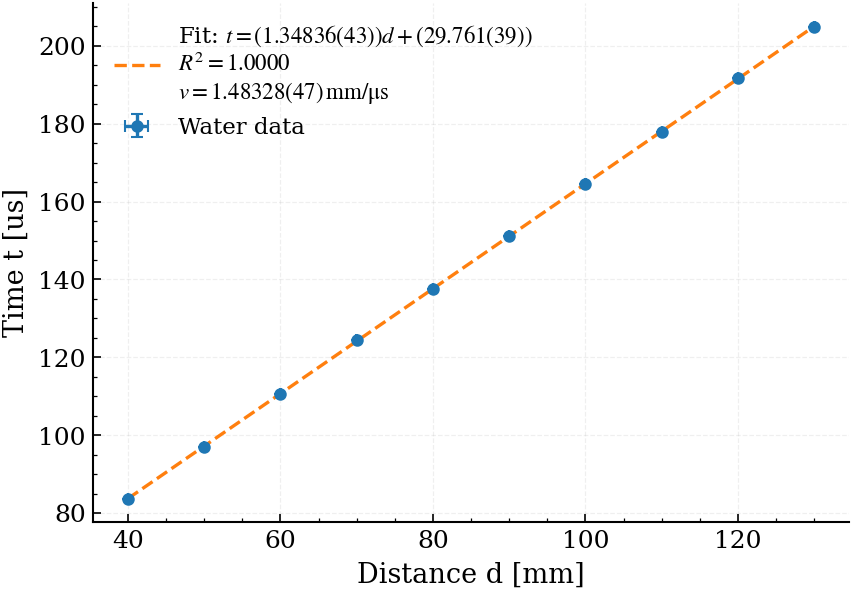

In [7]:
x_fit = np.linspace(x.min(), x.max(), 300)
y_fit = slope.n * x_fit + intercept.n

fit_label = (
    f"Fit: $t = ({ufloat_to_paren(slope)})d + ({ufloat_to_paren(intercept)})$\n"
    f"$R^2 = {r_squared:.4f}$\n"
    f"$v = {ufloat_to_paren(sound_speed)}\\,\\mathrm{{mm/\\mu s}}$"
)

fig, ax = create_figure(
    xlabel="Distance d [mm]",
    ylabel="Time t [us]",
    figsize=(6.5, 4.5),
)

ax.errorbar(
    x,
    y,
    xerr=distance_sigma,
    yerr=time_sigma,
    fmt="o",
    capsize=3,
    color="tab:blue",
    label="Water data",
)
ax.plot(x_fit, y_fit, linestyle="--", color="tab:orange", label=fit_label)
ax.legend(loc="upper left")

output_path = save_figure(
    fig,
    "water_regression_tutorial.pdf",
    directory=PROJECT_ROOT / "reports" / "figures",
)
output_path

## 延伸建議

之後如果你要把這份教學改成別的實驗版本，通常只需要替換：

- 資料檔路徑
- 欄位名稱
- 量測解析度
- 軸標籤與圖大小

而 `fitting.py`、`formatting.py`、`plot_settings.py` 的用法可以大致保持不變。